In [1]:
#Clone the project

!git clone https://github.com/Swkratis210204/data-mining-cs-aueb.git

Cloning into 'data-mining-cs-aueb'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (30/30), done.
Receiving objects: 100% (36/36), 326.36 KiB | 2.63 MiB/s, done.
remote: Total 36 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (10/10), done.


In [2]:
#Clone the data

!git clone --depth 1 https://github.com/papyri/idp.data.git

Cloning into 'idp.data'...
remote: Enumerating objects: 305151, done.
remote: Counting objects: 100% (305151/305151), done.
remote: Compressing objects: 100% (103844/103844), done.
remote: Total 305151 (delta 247799), reused 219980 (delta 201107), pack-reused 0 (from 0)
Receiving objects: 100% (305151/305151), 226.47 MiB | 12.25 MiB/s, done.
Resolving deltas: 100% (247799/247799), done.
Updating files: 100% (303345/303345), done.


In [3]:
#See the contents of the folder

!ls idp.data

APD	charDecl.xml	g-types		 HGV_trans_EpiDoc  Validation
APIS	DCLP		HGV_metadata	 RDF
Biblio	DDB_EpiDoc_XML	HGV_meta_EpiDoc  README.md


In [31]:
#See the structure of the data file

!find idp.data/DDB_EpiDoc_XML -name "*.xml" | head -20

idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.10.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.8.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.13.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.19.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.30.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.4.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.20.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.17.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.14.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.47.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.1.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.50.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.43.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.42.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.26.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.28.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.34.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.40.xml
idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.45.

In [30]:
#See the structure of the metadata file

!find idp.data/HGV_meta_EpiDoc -name "*.xml" | head -20

idp.data/HGV_meta_EpiDoc/HGV90/89225.xml
idp.data/HGV_meta_EpiDoc/HGV90/89194.xml
idp.data/HGV_meta_EpiDoc/HGV90/89222.xml
idp.data/HGV_meta_EpiDoc/HGV90/89181.xml
idp.data/HGV_meta_EpiDoc/HGV90/89186.xml
idp.data/HGV_meta_EpiDoc/HGV90/89247.xml
idp.data/HGV_meta_EpiDoc/HGV90/89182.xml
idp.data/HGV_meta_EpiDoc/HGV90/89190.xml
idp.data/HGV_meta_EpiDoc/HGV90/89159.xml
idp.data/HGV_meta_EpiDoc/HGV90/89176.xml
idp.data/HGV_meta_EpiDoc/HGV90/89155.xml
idp.data/HGV_meta_EpiDoc/HGV90/89207.xml
idp.data/HGV_meta_EpiDoc/HGV90/89252.xml
idp.data/HGV_meta_EpiDoc/HGV90/89238.xml
idp.data/HGV_meta_EpiDoc/HGV90/89219.xml
idp.data/HGV_meta_EpiDoc/HGV90/89284.xml
idp.data/HGV_meta_EpiDoc/HGV90/89154.xml
idp.data/HGV_meta_EpiDoc/HGV90/89244.xml
idp.data/HGV_meta_EpiDoc/HGV90/89265.xml
idp.data/HGV_meta_EpiDoc/HGV90/89256.xml


In [4]:
#See the content of the papyri text and their metadata

!find idp.data/DDB_EpiDoc_XML -name "*.xml" | wc -l
!find idp.data/HGV_meta_EpiDoc -name "*.xml" | wc -l

70546
66100


In [43]:
import os
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import re
import matplotlib.pyplot as plt

In [36]:
#XML Parser

def parse_papyrus(ddb_path, hgv_path):
    NS = {'tei': 'http://www.tei-c.org/ns/1.0'}

    root = ET.parse(ddb_path).getroot()
    title = root.find('.//tei:title', NS).text
    filename = root.find('.//tei:idno[@type="filename"]', NS).text
    hgv = root.find('.//tei:idno[@type="HGV"]', NS).text
    languages = [l.get('ident') for l in root.findall('.//tei:language', NS)]
    text = re.sub(r'\s+', ' ', ' '.join(root.find('.//tei:ab', NS).itertext())).strip()

    date_text = date_from = date_to = place_text = None
    if hgv_path is not None:
        hgv_root = ET.parse(hgv_path).getroot()
        date = hgv_root.find('.//tei:origDate', NS)
        date_text = re.sub(r'\s+', ' ', ' '.join(date.itertext())).strip() if date is not None else None
        date_from = date.get('notBefore') if date is not None else None
        date_to = date.get('notAfter') if date is not None else None
        place = hgv_root.find('.//tei:origPlace', NS)
        place_text = re.sub(r'\s+', ' ', ' '.join(place.itertext())).strip() if place is not None else None

    return {
        'title': title, 'filename': filename, 'hgv': hgv,
        'languages': languages, 'date_text': date_text,
        'date_from': date_from, 'date_to': date_to,
        'place': place_text, 'text': text
    }

In [37]:
#Run an example of the parsing result

result = parse_papyrus(
    'idp.data/DDB_EpiDoc_XML/p.clackson/p.clackson.10.xml',
    'idp.data/HGV_meta_EpiDoc/HGV119/118262.xml'
)
print(result)

{'title': 'p.clackson.10', 'filename': 'p.clackson.10', 'hgv': '118262', 'languages': ['en', 'cop', 'grc'], 'date_text': 'VIII', 'date_from': '0701', 'date_to': '0800', 'place': 'Bawit (Hermopolites, Ägypten)', 'text': 'ϣ ⲓ ⲛⲉ ⲛⲥⲁ ⲥⲉ ⲛϭⲟⲩⲛⲉ ⲛⲥⲟⲩⲟ ⲛⲧⲉ ⲫⲟⲓ ⲛⲙⲁⲕⲁⲣⲉ ⲉⲣ ⲉ σί του ἀρτ άβαι ογ 𐅵 ϩⲓⲱⲟⲩ πρώτ η α φορά φ ω ρά ϩⲓⲧⲛ ⲡⲁⲥⲟⲛ ⲓ ⲱⲁⲛⲏⲥ ⲡⲉ πιστικός ⲡⲓⲥⲧⲓⲕⲟⲥ γί νεται θαλλί α ξ . Μεσορ ή ιε .'}


In [38]:
# Finds all the pairs in the form of (ddb_path, hgv_path) from the folder DDB_EpiDoc_XML
def crawl(ddb_folder):
    pairs = []
    for ddb_path in Path(ddb_folder).rglob('*.xml'):
        try:
            root = ET.parse(ddb_path).getroot()
            NS = {'tei': 'http://www.tei-c.org/ns/1.0'}
            hgv = root.find('.//tei:idno[@type="HGV"]', NS).text
            hgv_path = Path(f'idp.data/HGV_meta_EpiDoc/HGV{int(hgv)//1000 + 1}/{hgv}.xml')
            pairs.append((ddb_path, hgv_path if hgv_path.exists() else None))
        except:
            pairs.append((ddb_path, None))
    return pairs


# Extracts all the information from each pair and returns a Dataframe
def scrape(pairs):
    records = []
    for ddb_path, hgv_path in pairs:
        try:
            records.append(parse_papyrus(ddb_path, hgv_path))
        except:
            pass
    return pd.DataFrame(records)

In [39]:
#Runs the crawler for the whole folder to get all the pairs and extracts the info

pairs = crawl('idp.data/DDB_EpiDoc_XML')
df = scrape(pairs)

print(f"Πλήρεις εγγραφές: {df.dropna(subset=['date_text', 'place']).shape[0]}")
print(f"Χωρίς metadata:   {df[df['date_text'].isna()].shape[0]}")

Πλήρεις εγγραφές: 68032
Χωρίς metadata:   2416


In [42]:
#Save results in a csv

df.to_csv('papyri.csv', index=False)

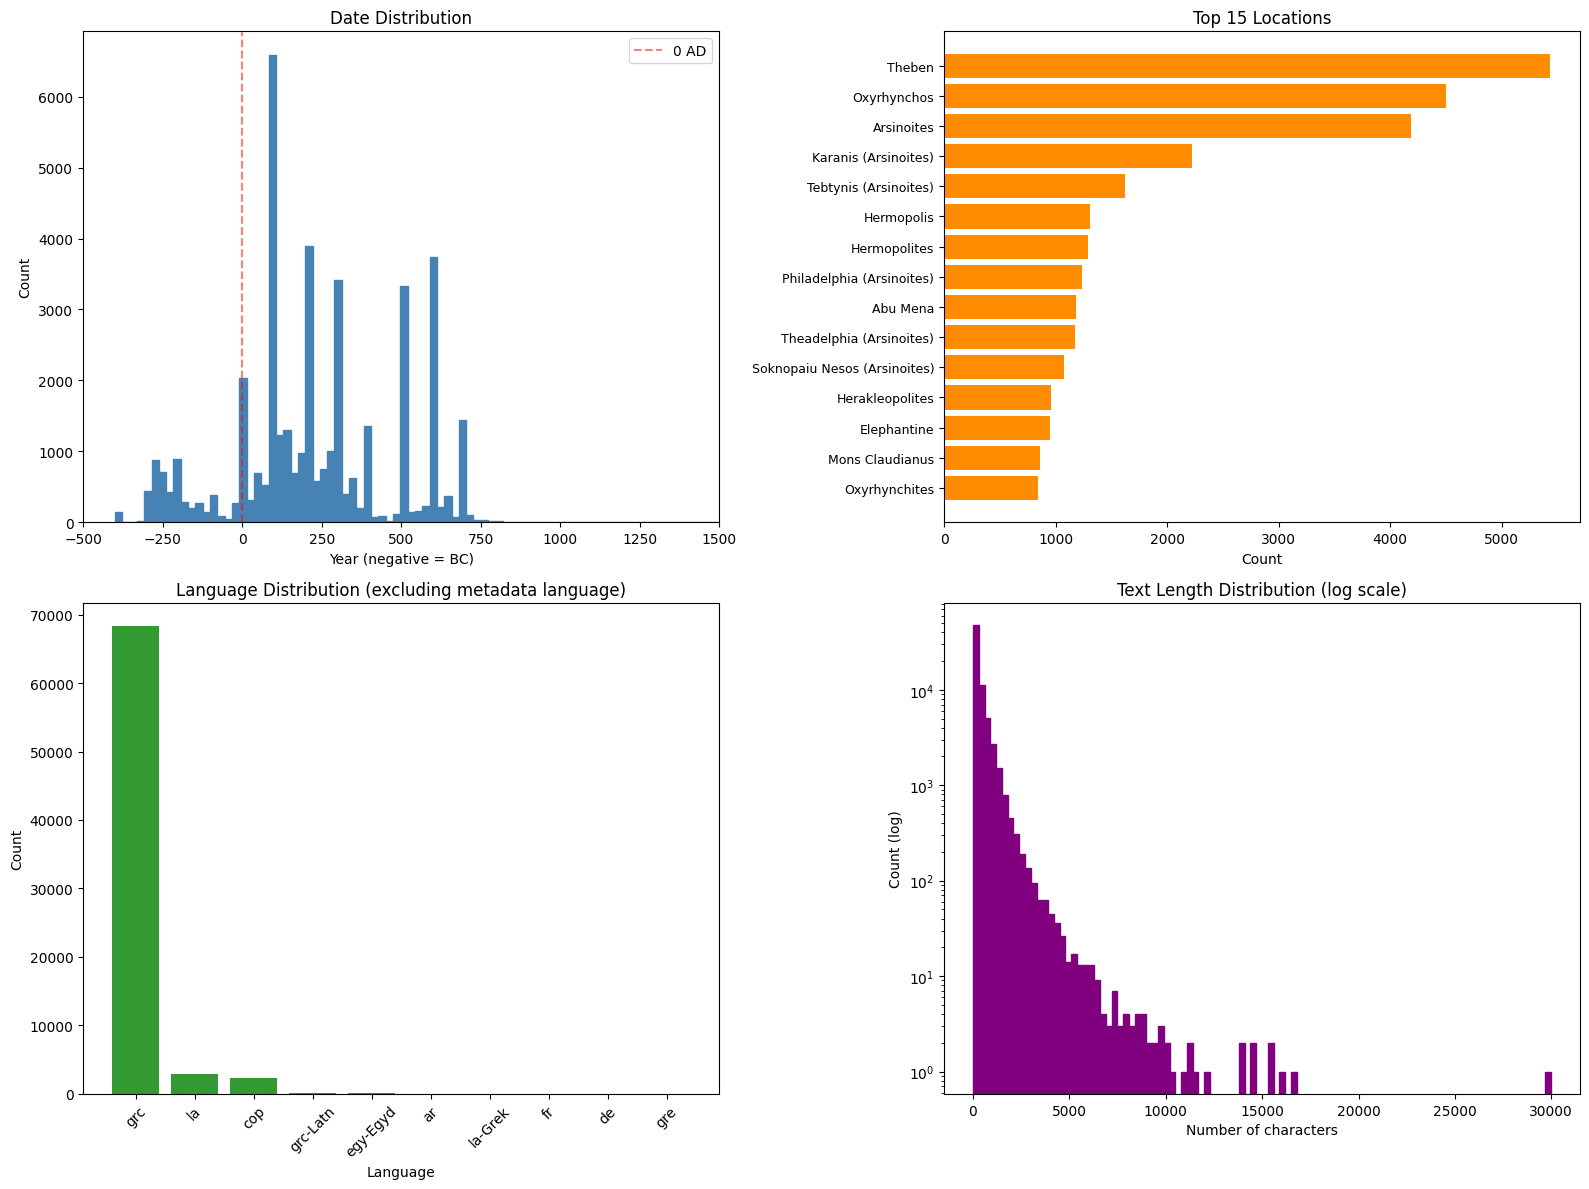

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Date Distribution
df_dates = df[df['date_from'].notna()].copy()
df_dates['date_from_num'] = pd.to_numeric(df_dates['date_from'], errors='coerce')
axes[0, 0].hist(df_dates['date_from_num'].dropna(), bins=100, color='steelblue', edgecolor='steelblue')
axes[0, 0].axvline(0, color='red', linestyle='--', alpha=0.5, label='0 AD')
axes[0, 0].set_title('Date Distribution')
axes[0, 0].set_xlabel('Year (negative = BC)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlim(-500, 1500)
axes[0, 0].legend()

# 2. Top 15 Locations
mask = df['place'].notna() & ~df['place'].str.contains('unbekannt', case=False, na=False)
top_places = df[mask]['place'].value_counts().head(15)
axes[0, 1].barh(top_places.index[::-1], top_places.values[::-1], color='darkorange')
axes[0, 1].set_title('Top 15 Locations')
axes[0, 1].set_xlabel('Count')
axes[0, 1].tick_params(axis='y', labelsize=9)

# 3. Language Distribution
languages_flat = [lang for langs in df['languages'] for lang in langs if lang != 'en']
lang_counts = pd.Series(languages_flat).value_counts().head(10)
axes[1, 0].bar(lang_counts.index, lang_counts.values, color='green', alpha=0.8)
axes[1, 0].set_title('Language Distribution (excluding metadata language)')
axes[1, 0].set_xlabel('Language')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Text Length Distribution (log scale)
df['text_length'] = df['text'].dropna().apply(len)
axes[1, 1].hist(df['text_length'].dropna(), bins=100, color='purple', edgecolor='purple')
axes[1, 1].set_title('Text Length Distribution (log scale)')
axes[1, 1].set_xlabel('Number of characters')
axes[1, 1].set_ylabel('Count (log)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight', dpi=150)
plt.show()

## EDA Findings

- **70,448 documents** processed, 68,032 with full metadata.
- Most papyri date between **0–700 AD**, with a peak around the 1st–2nd century AD.
- **Theben** and **Oxyrhynchos** are the dominant findspots, reflecting their role
  as major administrative centers in ancient Egypt.
- The vast majority of texts are written in **Ancient Greek (grc)**,
  followed by Latin (la) and Coptic (cop).
- Most texts are short (<1000 characters), consistent with the administrative
  and documentary nature of papyri (receipts, contracts, letters).